# Forecasting Monthly Sales and Sizing Promotions for a 1,115-Store Retailer

**Business context.** A retail chain runs a chain-wide promotion roughly every other week. The marketing
team wants answers to four questions:

1. **How much does a promotion actually lift sales, and for which store formats?** (evaluating a marketing lever)
2. **How accurately can we forecast next month's sales for every store, given the planned promo calendar?**
   (supporting a monthly forecasting process)
3. **What is an upcoming campaign worth?** The July promo calendar, and a proposed extra promo week.
4. **How would we test a promotion change rigorously?** (experimental design and power analysis)

**Data.** Rossmann Store Sales (Kaggle): 1,017,209 daily store records from Jan 2013 to Jul 2015, plus store
attributes. Download `train.csv` and `store.csv` from https://www.kaggle.com/c/rossmann-store-sales/data
into a `data/` folder next to this notebook.

**Tools.** SQL (DuckDB) for data preparation, Python (pandas, statsmodels, LightGBM, SciPy) for modeling.

In [4]:
!pip install -q duckdb

## 1. Setup

In [5]:
from pathlib import Path

import duckdb
import lightgbm as lgb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

DATA_DIR = Path("data")
missing = [f for f in ["train.csv", "store.csv"] if not (DATA_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f"Missing {missing}. Download them from "
                            f"https://www.kaggle.com/c/rossmann-store-sales/data into {DATA_DIR.resolve()}")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
RNG = np.random.default_rng(42)

plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})
COLORS = {"seasonal_naive": "#9aa5b1", "recent_avg": "#5b8def", "lightgbm": "#d9480f"}


def wape(actual, forecast):
    """Weighted absolute percentage error: total absolute error / total actual sales."""
    actual, forecast = np.asarray(actual, float), np.asarray(forecast, float)
    return np.abs(actual - forecast).sum() / actual.sum()

## 2. Load and prepare the data with SQL

DuckDB runs SQL directly on the CSV files, which keeps data prep readable and fast on 1M+ rows.
`StateHoliday` mixes numbers and letters in the raw file, so it is read explicitly as text.

In [6]:
con = duckdb.connect()
con.execute(f"""
    CREATE OR REPLACE TABLE sales AS
    SELECT * FROM read_csv('{DATA_DIR / "train.csv"}', types={{'StateHoliday': 'VARCHAR'}})
""")
con.execute(f"CREATE OR REPLACE TABLE stores AS SELECT * FROM read_csv('{DATA_DIR / 'store.csv'}')")

con.sql("""
    SELECT count(*) AS store_days, count(DISTINCT Store) AS stores,
           min(Date) AS first_day, max(Date) AS last_day
    FROM sales
""").df()

,store_days,stores,first_day,last_day
0,1017209,1115,2013-01-01,2015-07-31


### Data quality checks

In [7]:
# 1) Do all stores have a full history?
con.sql("""
    SELECT days_of_data, count(*) AS stores
    FROM (SELECT Store, count(*) AS days_of_data FROM sales GROUP BY Store)
    GROUP BY days_of_data ORDER BY days_of_data
""").df()

,days_of_data,stores
0,758,180
1,941,1
2,942,934


In [8]:
# 2) When are the gaps? (stores with missing days, by month)
con.sql("""
    SELECT date_trunc('month', Date) AS month, count(DISTINCT Store) AS stores_reporting
    FROM sales
    WHERE Date BETWEEN DATE '2014-05-01' AND DATE '2015-02-28'
    GROUP BY 1 ORDER BY 1
""").df()

,month,stores_reporting
0,2014-05-01,1115
1,2014-06-01,1115
2,2014-07-01,935
3,2014-08-01,935
4,2014-09-01,935
5,2014-10-01,935
6,2014-11-01,935
7,2014-12-01,935
8,2015-01-01,1115
9,2015-02-01,1115


In [9]:
# 3) Open days with zero sales (likely data errors) and the promo calendar structure
con.sql("""
    SELECT
        (SELECT count(*) FROM sales WHERE Open = 1 AND Sales = 0) AS open_days_with_zero_sales,
        (SELECT count(*) FROM (
            SELECT Date FROM sales WHERE Open = 1 GROUP BY Date
            HAVING avg(Promo) NOT IN (0, 1))) AS dates_with_mixed_promo_status
""").df()

,open_days_with_zero_sales,dates_with_mixed_promo_status
0,54,0


**What the checks show**
- 180 stores have no data from Jul to Dec 2014 (temporarily closed for refurbishment). Models must handle the gap.
- A small number of open days show zero sales. They are excluded as likely recording errors.
- On every date, either **all** stores run the promotion or **none** do. The promo is a chain-wide calendar
  decision, which matters for how we estimate its effect (Section 4).

### Build the modeling table

One row per open store-day, joined to store attributes. Two derived features:
- `CompetitionOpenMonths`: months since the nearest competitor opened.
- `Promo2Active`: whether the store's separate, recurring loyalty promotion ("Promo2") is running that month.
  Note that the raw file spells September as `Sept`.

In [10]:
con.execute("""
    CREATE OR REPLACE TABLE model_data AS
    SELECT s.Store, s.Date, s.DayOfWeek, s.Sales, s.Promo, s.StateHoliday, s.SchoolHoliday,
           year(s.Date) AS Year, month(s.Date) AS Month, day(s.Date) AS Day,
           weekofyear(s.Date) AS WeekOfYear, yearweek(s.Date) AS YearWeek,
           st.StoreType, st.Assortment, st.CompetitionDistance,
           CASE WHEN st.CompetitionOpenSinceYear IS NULL THEN NULL
                ELSE (year(s.Date) - st.CompetitionOpenSinceYear) * 12
                     + (month(s.Date) - st.CompetitionOpenSinceMonth)
           END AS CompetitionOpenMonths,
           CASE WHEN st.Promo2 = 1
                 AND year(s.Date) * 100 + weekofyear(s.Date)
                     >= st.Promo2SinceYear * 100 + st.Promo2SinceWeek
                 AND list_contains(string_split(st.PromoInterval, ','),
                       ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sept','Oct','Nov','Dec'][month(s.Date)])
                THEN 1 ELSE 0
           END AS Promo2Active
    FROM sales s
    JOIN stores st USING (Store)
    WHERE s.Open = 1 AND s.Sales > 0
""")

df = con.sql("SELECT * FROM model_data ORDER BY Store, Date").df()
df["Date"] = pd.to_datetime(df["Date"])
for col in ["CompetitionDistance", "CompetitionOpenMonths"]:
    df[col] = df[col].astype(float)
df["log_sales"] = np.log(df["Sales"])
df["ym"] = df["Year"] * 12 + df["Month"] - 1  # running month index
print(f"{len(df):,} open store-days for modeling")
df.head()

844,338 open store-days for modeling


,Store,Date,DayOfWeek,Sales,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,WeekOfYear,YearWeek,StoreType,Assortment,CompetitionDistance,CompetitionOpenMonths,Promo2Active,log_sales,ym
0,1,2013-01-02,3,5530,0,0,1,2013,1,2,1,201301,c,a,1270.0,52.0,0,8.617943,24156
1,1,2013-01-03,4,4327,0,0,1,2013,1,3,1,201301,c,a,1270.0,52.0,0,8.372630,24156
2,1,2013-01-04,5,4486,0,0,1,2013,1,4,1,201301,c,a,1270.0,52.0,0,8.408717,24156
3,1,2013-01-05,6,4997,0,0,1,2013,1,5,1,201301,c,a,1270.0,52.0,0,8.516593,24156
4,1,2013-01-07,1,7176,1,0,1,2013,1,7,2,201302,c,a,1270.0,52.0,0,8.878497,24156


## 3. Explore: seasonality and the promo calendar

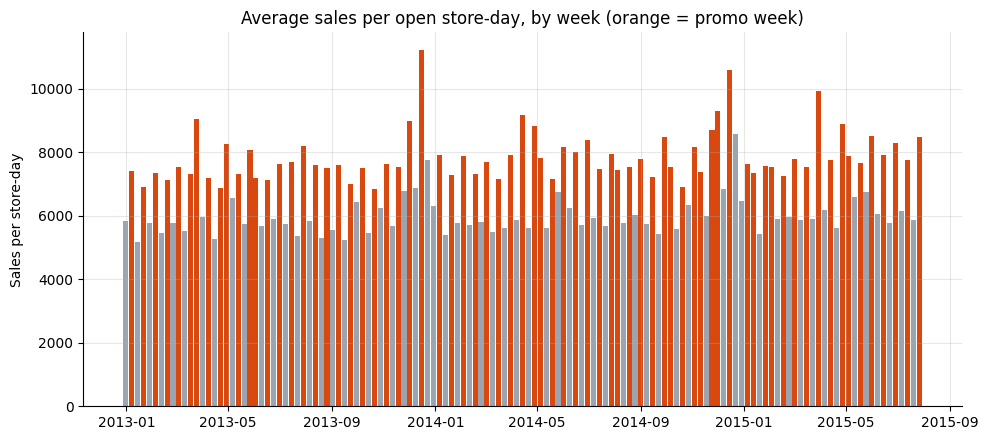

In [11]:
weekly = con.sql("""
    SELECT date_trunc('week', Date) AS week,
           avg(Sales) FILTER (WHERE Open = 1 AND Sales > 0) AS avg_sales_per_store_day,
           max(Promo) AS promo_week
    FROM sales GROUP BY 1 ORDER BY 1
""").df()
weekly["week"] = pd.to_datetime(weekly["week"])

fig, ax = plt.subplots()
ax.bar(weekly["week"], weekly["avg_sales_per_store_day"], width=6,
       color=np.where(weekly["promo_week"] == 1, COLORS["lightgbm"], "#9aa5b1"))
ax.set_title("Average sales per open store-day, by week (orange = promo week)")
ax.set_ylabel("Sales per store-day")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_weekly_sales_promo.png", dpi=150)
plt.show()

In [12]:
# Raw comparison by weekday. Promos only run Monday to Friday.
con.sql("""
    SELECT DayOfWeek,
           round(avg(Sales) FILTER (WHERE Promo = 0)) AS avg_sales_no_promo,
           round(avg(Sales) FILTER (WHERE Promo = 1)) AS avg_sales_promo,
           round(avg(Sales) FILTER (WHERE Promo = 1) / avg(Sales) FILTER (WHERE Promo = 0) - 1, 3) AS raw_lift
    FROM model_data GROUP BY 1 ORDER BY 1
""").df()

,DayOfWeek,avg_sales_no_promo,avg_sales_promo,raw_lift
0,1,6223.0,9773.0,0.571
1,2,5716.0,8278.0,0.448
2,3,5618.0,7686.0,0.368
3,4,5751.0,7599.0,0.321
4,5,6344.0,7744.0,0.221
5,6,5875.0,NaN,NaN
6,7,8225.0,NaN,NaN


Sales peak in December, and promo weeks stand out clearly. But the raw comparison mixes the promo
effect with weekday and seasonal patterns, so we need a model that holds those constant.

## 4. How much does a promotion lift sales?

**Model.** A log-linear regression with fixed effects:

`log(sales) ~ promo + day-of-week + year-month + state holiday + school holiday + store fixed effects`

- **Log sales** means the promo coefficient reads as a percentage lift: lift = exp(coef) - 1.
- **Store fixed effects** compare each store with itself, so large and small stores don't distort the estimate.
  They are applied with the within transformation (subtract each store's average), which avoids 1,115 dummy columns.
- **Year-month effects** absorb seasonality and trend. **Day-of-week effects** matter because promos never run on weekends.
- **Standard errors are clustered by week.** Promos are switched on for the whole chain at once, so the
  844K rows contain only about 135 independent promo decisions. Ignoring that would make the estimate look far
  more precise than it is.

In [13]:
controls = pd.get_dummies(df[["DayOfWeek", "StateHoliday", "ym"]].astype(str), drop_first=True, dtype=float)
controls["SchoolHoliday"] = df["SchoolHoliday"].astype(float)


def fe_regression(treatment: pd.DataFrame):
    """OLS of log sales with store fixed effects (within transformation) and week-clustered SEs."""
    X_reg = pd.concat([treatment, controls], axis=1)
    X_within = X_reg - X_reg.groupby(df["Store"]).transform("mean")
    y_within = df["log_sales"] - df.groupby("Store")["log_sales"].transform("mean")
    return sm.OLS(y_within, X_within).fit(cov_type="cluster", cov_kwds={"groups": df["YearWeek"]})


def lift_with_ci(result, name):
    coef, se = result.params[name], result.bse[name]
    return np.exp(coef) - 1, np.exp(coef - 1.96 * se) - 1, np.exp(coef + 1.96 * se) - 1


overall = fe_regression(df[["Promo"]].astype(float))
promo_lift, promo_lo, promo_hi = lift_with_ci(overall, "Promo")
print(f"Promo lift: {promo_lift:.1%} (95% CI {promo_lo:.1%} to {promo_hi:.1%})")

Promo lift: 39.3% (95% CI 36.7% to 42.0%)


### Does the lift differ by store format?

store_type  stores  lift  ci_low  ci_high
         a     602 0.439   0.412    0.466
         b      17 0.133   0.105    0.161
         c     148 0.333   0.303    0.365
         d     348 0.354   0.325    0.385


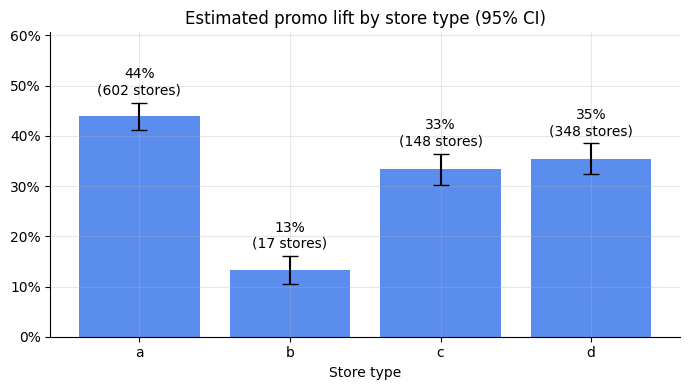

In [14]:
store_types = sorted(df["StoreType"].unique())
by_type = pd.DataFrame({f"Promo_type_{t}": (df["Promo"] * (df["StoreType"] == t)).astype(float)
                        for t in store_types})
het = fe_regression(by_type)

lift_by_type = pd.DataFrame(
    [(t, df.loc[df.StoreType == t, "Store"].nunique(), *lift_with_ci(het, f"Promo_type_{t}"))
     for t in store_types],
    columns=["store_type", "stores", "lift", "ci_low", "ci_high"])
print(lift_by_type.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(lift_by_type["store_type"], lift_by_type["lift"], color="#5b8def",
       yerr=[lift_by_type["lift"] - lift_by_type["ci_low"], lift_by_type["ci_high"] - lift_by_type["lift"]],
       capsize=6)
for i, r in lift_by_type.iterrows():
    ax.text(i, r["ci_high"] + 0.01, f"{r['lift']:.0%}\n({r['stores']} stores)", ha="center", va="bottom")
ax.set_ylim(0, lift_by_type["ci_high"].max() * 1.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("Estimated promo lift by store type (95% CI)")
ax.set_xlabel("Store type")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_promo_lift_by_store_type.png", dpi=150)
plt.show()

**Caveats.** This is an observational estimate, not a randomized one. If promo weeks coincide with something
else (paydays, competitor activity), the estimate absorbs it. It also measures lift on promo days only; if
promos pull purchases forward from the following week, true incremental sales are lower. Section 7 designs a
test that would settle both questions.

## 5. Forecasting next month: a rolling-origin backtest

**Setup.** This simulates a monthly forecasting process. At the start of each month from Feb to Jul 2015,
we train on everything before that month and forecast every open store-day in it, then sum to
store-month totals. Six months, six independent tests.

**Only information known in advance is used:** the calendar, the planned promo calendar, store attributes,
and sales from before the forecast month. The `Customers` column is excluded because it is not known ahead
of time; using it would leak the answer.

**Models compared**
1. **Seasonal naive:** same weekday last year (364 days earlier).
2. **Recent average:** each store's average by weekday and promo status over the last 12 weeks.
3. **LightGBM:** gradient boosting on calendar, promo, holiday, and store features, plus two leakage-safe
   "recent level" features computed only from the three months *before* each row's month.

**Metrics.** WAPE (total absolute error divided by total sales) at store-day and store-month level, plus the
chain-level monthly error, which shows bias.

In [15]:
# Leakage-safe level features: for each store and month, use only the 3 calendar months before it.
monthly = df.groupby(["Store", "ym"])["log_sales"].mean().rename("all").to_frame()
monthly = monthly.join(df.groupby(["Store", "ym", "Promo"])["log_sales"].mean()
                       .unstack("Promo").rename(columns={0: "no_promo", 1: "promo"}))
full_grid = pd.MultiIndex.from_product([sorted(df["Store"].unique()), range(df["ym"].min(), df["ym"].max() + 1)],
                                       names=["Store", "ym"])
monthly = monthly.reindex(full_grid).reset_index()  # calendar months even when a store has gaps
for col in ["all", "promo", "no_promo"]:
    monthly[f"{col}_prev3"] = monthly.groupby("Store")[col].transform(
        lambda s: s.shift(1).rolling(3, min_periods=1).mean())
monthly["level_3m"] = monthly["all_prev3"]
monthly["promo_gap_3m"] = monthly["promo_prev3"] - monthly["no_promo_prev3"]
df = df.merge(monthly[["Store", "ym", "level_3m", "promo_gap_3m"]], on=["Store", "ym"], how="left")

FEATURES = ["Store", "DayOfWeek", "Day", "Month", "WeekOfYear", "Promo", "Promo2Active", "StateHoliday",
            "SchoolHoliday", "StoreType", "Assortment", "CompetitionDistance", "CompetitionOpenMonths",
            "level_3m", "promo_gap_3m"]
CAT_FEATURES = ["Store", "StateHoliday", "StoreType", "Assortment"]
X = df[FEATURES].copy()
for col in CAT_FEATURES:
    X[col] = X[col].astype("category")
y = df["log_sales"]

LGB_PARAMS = dict(objective="regression", learning_rate=0.1, num_leaves=63, min_data_in_leaf=100,
                  feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1, seed=42, verbose=-1)
N_ROUNDS = 400

# Sales from 364 days earlier (same weekday last year) for the seasonal naive baseline
last_year = df[["Store", "Date", "Sales"]].assign(Date=lambda d: d["Date"] + pd.Timedelta(days=364))
last_year = last_year.rename(columns={"Sales": "sales_last_year"})

In [16]:
MODELS = ["seasonal_naive", "recent_avg", "lightgbm"]


def forecast_month(cutoff):
    """Train on data before `cutoff`, forecast every open store-day in the following month."""
    end = cutoff + pd.offsets.MonthBegin(1)
    train, test = df["Date"] < cutoff, (df["Date"] >= cutoff) & (df["Date"] < end)
    out = df.loc[test, ["Store", "Date", "DayOfWeek", "Promo", "Sales"]].copy()

    # Recent-average baseline, with fallbacks when a store has no matching recent days
    recent = df[(df["Date"] < cutoff) & (df["Date"] >= cutoff - pd.Timedelta(weeks=12))]
    out = out.join(recent.groupby(["Store", "DayOfWeek", "Promo"])["Sales"].mean().rename("r1"),
                   on=["Store", "DayOfWeek", "Promo"])
    out = out.join(recent.groupby(["Store", "DayOfWeek"])["Sales"].mean().rename("r2"), on=["Store", "DayOfWeek"])
    out = out.join(recent.groupby("Store")["Sales"].mean().rename("r3"), on="Store")
    out["recent_avg"] = out["r1"].fillna(out["r2"]).fillna(out["r3"])

    # Seasonal naive, falling back to the recent average when last year's day is missing or closed
    out = out.merge(last_year, on=["Store", "Date"], how="left")
    out["seasonal_naive"] = out["sales_last_year"].fillna(out["r2"]).fillna(out["r3"])

    model = lgb.train(LGB_PARAMS, lgb.Dataset(X.loc[train], y[train], categorical_feature=CAT_FEATURES),
                      num_boost_round=N_ROUNDS)
    out["lightgbm"] = np.exp(model.predict(X.loc[test]))
    assert out[MODELS].notna().all().all()
    return out.drop(columns=["r1", "r2", "r3", "sales_last_year"]), model


cutoffs = pd.date_range("2015-02-01", "2015-07-01", freq="MS")
forecasts, models, rows = {}, {}, []
for cutoff in cutoffs:
    out, model = forecast_month(cutoff)
    forecasts[cutoff], models[cutoff] = out, model
    store_month = out.groupby("Store")[["Sales"] + MODELS].sum()
    for m in MODELS:
        rows.append({"month": cutoff.strftime("%Y-%m"), "model": m,
                     "store_day_wape": wape(out["Sales"], out[m]),
                     "store_month_wape": wape(store_month["Sales"], store_month[m]),
                     "chain_month_error": store_month[m].sum() / store_month["Sales"].sum() - 1})
    print(f"{cutoff:%Y-%m} done")

backtest = pd.DataFrame(rows)

2015-02 done
2015-03 done
2015-04 done
2015-05 done
2015-06 done
2015-07 done


In [17]:
summary = (backtest.assign(abs_chain_error=backtest["chain_month_error"].abs())
           .groupby("model")[["store_day_wape", "store_month_wape", "abs_chain_error"]].mean()
           .loc[MODELS])
print("Average over 6 monthly backtests:")
print((summary * 100).round(1).astype(str) + "%")
backtest.pivot(index="month", columns="model", values="store_month_wape")[MODELS].round(3)

Average over 6 monthly backtests:
               store_day_wape store_month_wape abs_chain_error
model                                                         
seasonal_naive          12.8%             5.5%            2.5%
recent_avg              11.3%             5.8%            4.3%
lightgbm                 8.8%             3.7%            2.0%


model,seasonal_naive,recent_avg,lightgbm
month,,,
2015-02,0.050,0.096,0.037
2015-03,0.069,0.042,0.033
2015-04,0.045,0.085,0.034
2015-05,0.068,0.043,0.047
2015-06,0.045,0.033,0.033
2015-07,0.055,0.048,0.037


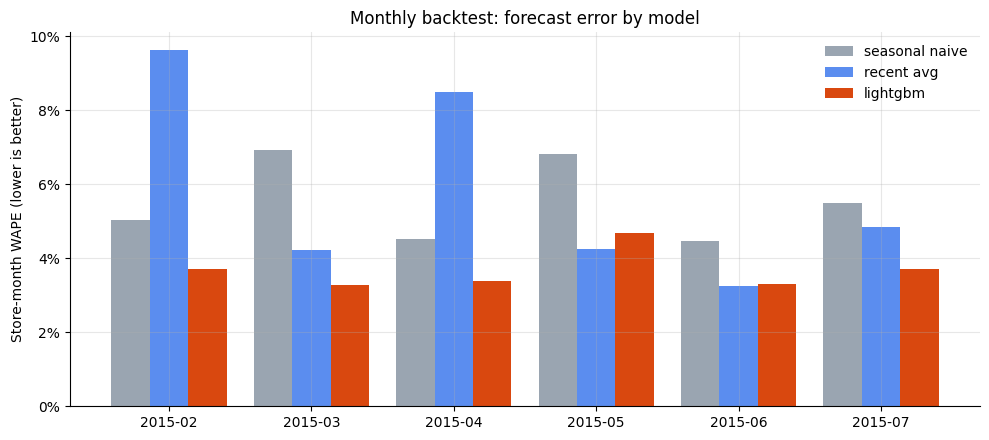

In [18]:
pivot = backtest.pivot(index="month", columns="model", values="store_month_wape")[MODELS]
fig, ax = plt.subplots()
width = 0.27
for i, m in enumerate(MODELS):
    ax.bar(np.arange(len(pivot)) + (i - 1) * width, pivot[m], width, label=m.replace("_", " "), color=COLORS[m])
ax.set_xticks(np.arange(len(pivot)), pivot.index)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylabel("Store-month WAPE (lower is better)")
ax.set_title("Monthly backtest: forecast error by model")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_backtest_wape.png", dpi=150)
plt.show()

In [19]:
# How close are individual store-month forecasts? (pooled over all 6 backtest months)
store_month_all = pd.concat([f.groupby("Store")[["Sales", "lightgbm"]].sum() for f in forecasts.values()])
pct_err = (store_month_all["lightgbm"] / store_month_all["Sales"] - 1).abs()
within = {t: (pct_err <= t).mean() for t in [0.05, 0.10]}
print(f"LightGBM store-month forecasts within ±5%: {within[0.05]:.0%}, within ±10%: {within[0.10]:.0%}")

best_baseline_wape = summary.loc[["seasonal_naive", "recent_avg"], "store_month_wape"].min()
lgb_wape = summary.loc["lightgbm", "store_month_wape"]
print(f"LightGBM cuts store-month error by {1 - lgb_wape / best_baseline_wape:.0%} vs. the best baseline")
lgb_wins = int((pivot["lightgbm"] <= pivot[["seasonal_naive", "recent_avg"]].min(axis=1)).sum())
print(f"LightGBM has the lowest store-month error in {lgb_wins} of {len(pivot)} months")

LightGBM store-month forecasts within ±5%: 74%, within ±10%: 97%
LightGBM cuts store-month error by 34% vs. the best baseline
LightGBM has the lowest store-month error in 4 of 6 months


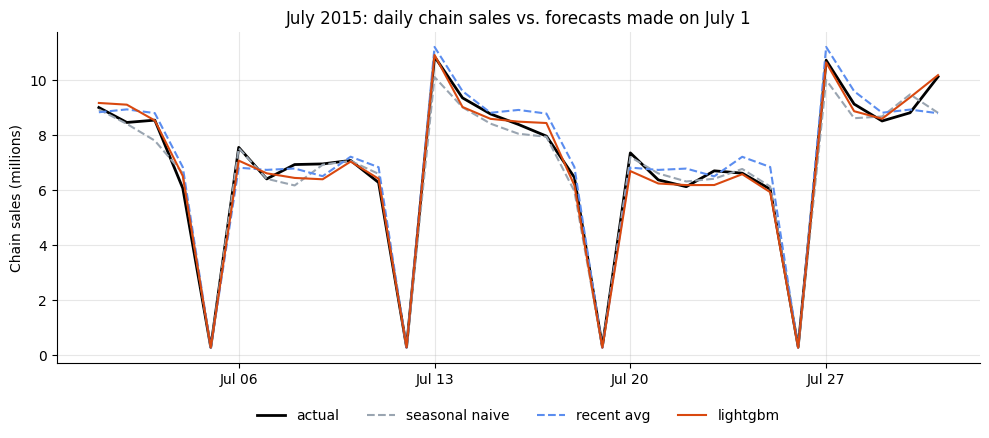

In [20]:
july = forecasts[pd.Timestamp("2015-07-01")]
daily = july.groupby("Date")[["Sales"] + MODELS].sum() / 1e6
fig, ax = plt.subplots()
ax.plot(daily.index, daily["Sales"], color="black", lw=2, label="actual")
for m in MODELS:
    ax.plot(daily.index, daily[m], color=COLORS[m], lw=1.5, ls="--" if m != "lightgbm" else "-",
            label=m.replace("_", " "))
ax.set_ylabel("Chain sales (millions)")
ax.set_title("July 2015: daily chain sales vs. forecasts made on July 1")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.1))
fig.tight_layout()
fig.savefig(FIG_DIR / "04_july_forecast_vs_actual.png", dpi=150)
plt.show()

**Takeaways.** Seasonal naive ignores this year's promo calendar, and the recent average ignores
seasonality. LightGBM uses both and has the lowest error on average, although the simple recent average wins
or ties in some months. That is why forecasts should always be compared against baselines. Feature choices
were made by comparing variants on these same backtest months, so treat the numbers as slightly optimistic.

## 6. Sizing an upcoming campaign

Using the model trained through June, we forecast July under three scenarios:
1. **Planned calendar:** the promo schedule that actually ran.
2. **No promo:** all promotions switched off.
3. **Extra promo week:** promo also switched on for the first full non-promo week (Monday to Friday).

The difference between scenarios estimates what each campaign decision is worth.

In [21]:
july_cut = pd.Timestamp("2015-07-01")
july_mask = df["Date"] >= july_cut
july_model = models[july_cut]
X_july = X.loc[july_mask].copy()


def scenario_total(X_scenario):
    return np.exp(july_model.predict(X_scenario)).sum()


planned = scenario_total(X_july)
no_promo = scenario_total(X_july.assign(Promo=0))

july_days = df.loc[july_mask, ["Date", "DayOfWeek", "Promo"]].copy()
july_days["week_start"] = july_days["Date"] - pd.to_timedelta(july_days["DayOfWeek"] - 1, unit="D")
promo_by_week = july_days.groupby("week_start")["Promo"].max()
full_weeks = [w for w in promo_by_week.index if w >= july_cut and w + pd.Timedelta(days=4) <= pd.Timestamp("2015-07-31")]
extra_week = next(w for w in full_weeks if promo_by_week[w] == 0)
X_extra = X_july.copy()
X_extra.loc[(july_days["week_start"] == extra_week) & (july_days["DayOfWeek"] <= 5), "Promo"] = 1
extra = scenario_total(X_extra)

actual_july = df.loc[july_mask, "Sales"].sum()
scenarios = pd.DataFrame({
    "forecast_sales_m": [planned / 1e6, no_promo / 1e6, extra / 1e6],
    "vs_no_promo_m": [(planned - no_promo) / 1e6, 0, (extra - no_promo) / 1e6],
}, index=["planned calendar", "no promo", f"extra week ({extra_week:%b %d})"])
print(scenarios.round(1))
print(f"\nActual July sales: {actual_july / 1e6:.1f}M (planned-calendar forecast error {planned / actual_july - 1:+.1%})")
print(f"Planned promo calendar worth {(planned - no_promo) / 1e6:.1f}M (+{planned / no_promo - 1:.1%} vs. the no-promo forecast)")
print(f"Extra promo week worth {(extra - planned) / 1e6:.1f}M more ({extra / planned - 1:.1%})")

                     forecast_sales_m  vs_no_promo_m
planned calendar                211.0           30.0
no promo                        181.0            0.0
extra week (Jul 06)             223.1           42.1

Actual July sales: 212.3M (planned-calendar forecast error -0.6%)
Planned promo calendar worth 30.0M (+16.6% vs. the no-promo forecast)
Extra promo week worth 12.0M more (5.7%)


In [22]:
# Cross-check: regression lift applied to the no-promo forecast on planned promo days
no_promo_daily = np.exp(july_model.predict(X_july.assign(Promo=0)))
regression_based = (no_promo_daily * (july_days["Promo"].values == 1) * promo_lift).sum()
print(f"Regression-based estimate of the planned calendar's value: {regression_based / 1e6:.1f}M "
      f"vs. LightGBM scenario: {(planned - no_promo) / 1e6:.1f}M")

# How often has the chain run back-to-back promo weeks? (tells us how much the model can learn about it)
promo_weeks = con.sql("""
    SELECT date_trunc('week', Date) AS week, max(Promo) AS promo
    FROM sales GROUP BY 1 ORDER BY 1
""").df()["promo"].values
back_to_back = int(((promo_weeks[1:] == 1) & (promo_weeks[:-1] == 1)).sum())
print(f"Back-to-back promo weeks in history: {back_to_back} of {len(promo_weeks)} weeks")

Regression-based estimate of the planned calendar's value: 35.2M vs. LightGBM scenario: 30.0M
Back-to-back promo weeks in history: 11 of 135 weeks


**Caveats.** The scenarios show what the model *predicts*, not proven causal effects. Back-to-back promo
weeks are rare in the history, so the extra-week estimate is partly an extrapolation. It cannot capture promo
fatigue or a post-promo dip. That uncertainty is exactly what an experiment should resolve.

## 7. Designing a test: store-level holdout with CUPED

**Proposed test.** Randomly assign stores to treatment (e.g., a new promo mechanic or an extra promo week) or
control. Measure total sales over a **two-week window**, so any post-promo dip is counted against the lift.

**Challenge.** Stores differ hugely in size, so raw store sales are very noisy and small effects are hard to see.

**CUPED** (Controlled-experiment Using Pre-Experiment Data) adjusts each store's outcome using its own
sales before the test: `adjusted = outcome - theta * pre_period`. This removes the size differences and keeps
the comparison unbiased, because pre-period sales can't be affected by the treatment.

We estimate the noise from 2015 history by treating every two-week window as a pretend test, using the
previous 8 weeks as the pre-period.

In [23]:
weekly_store = con.sql("""
    SELECT Store, date_trunc('week', Date) AS week, sum(Sales) AS sales
    FROM sales
    WHERE Date >= DATE '2015-01-05' AND Date < DATE '2015-07-27'   -- complete Monday-Sunday weeks
    GROUP BY 1, 2
""").df().pivot(index="Store", columns="week", values="sales").sort_index(axis=1)
weekly_store = weekly_store[(weekly_store > 0).all(axis=1)]  # stores open every week
print(f"{len(weekly_store)} stores x {weekly_store.shape[1]} weeks")

PRE_WEEKS, TEST_WEEKS = 8, 2
windows = []
for i in range(PRE_WEEKS, weekly_store.shape[1] - TEST_WEEKS + 1):
    y_w = np.log(weekly_store.iloc[:, i:i + TEST_WEEKS].sum(axis=1).values)
    x_w = np.log(weekly_store.iloc[:, i - PRE_WEEKS:i].sum(axis=1).values)
    theta = np.cov(x_w, y_w)[0, 1] / np.var(x_w, ddof=1)
    windows.append({"y": y_w, "x": x_w, "sd_raw": y_w.std(ddof=1),
                    "sd_cuped": (y_w - theta * x_w).std(ddof=1), "corr": np.corrcoef(x_w, y_w)[0, 1]})

sd_raw = np.median([w["sd_raw"] for w in windows])
sd_cuped = np.median([w["sd_cuped"] for w in windows])
print(f"SD of log 2-week store sales: raw {sd_raw:.3f}, CUPED-adjusted {sd_cuped:.3f} "
      f"(pre/post correlation {np.median([w['corr'] for w in windows]):.3f}, "
      f"variance reduced {1 - (sd_cuped / sd_raw) ** 2:.1%})")

1107 stores x 29 weeks
SD of log 2-week store sales: raw 0.323, CUPED-adjusted 0.044 (pre/post correlation 0.991, variance reduced 98.2%)


In [24]:
Z = stats.norm.ppf(0.975) + stats.norm.ppf(0.80)  # 5% two-sided significance, 80% power


def stores_per_arm(mde, sd):
    return int(np.ceil(2 * (Z * sd / np.log(1 + mde)) ** 2))


def mde_for(n_per_arm, sd):
    return np.exp(Z * sd * np.sqrt(2 / n_per_arm)) - 1


n_available = len(weekly_store) // 2
power_table = pd.DataFrame({"effect_to_detect": [0.01, 0.02, 0.03, 0.05]})
power_table["stores_per_arm_raw"] = power_table["effect_to_detect"].apply(lambda e: stores_per_arm(e, sd_raw))
power_table["stores_per_arm_cuped"] = power_table["effect_to_detect"].apply(lambda e: stores_per_arm(e, sd_cuped))
print(power_table.to_string(index=False))
print(f"\nWith all stores split 50/50 ({n_available} per arm), smallest detectable effect: "
      f"raw {mde_for(n_available, sd_raw):.1%}, CUPED {mde_for(n_available, sd_cuped):.1%}")

 effect_to_detect  stores_per_arm_raw  stores_per_arm_cuped
             0.01               16531                   304
             0.02                4174                    77
             0.03                1874                    35
             0.05                 688                    13

With all stores split 50/50 (553 per arm), smallest detectable effect: raw 5.6%, CUPED 0.7%


In [ ]:
# Validate with simulated tests on real history: A/A tests (no effect) should be significant ~5% of the time;
# tests with a true +3% effect show the realized power of each analysis.
N_SIMS, TRUE_EFFECT = 2000, 0.03
n_arm = stores_per_arm(TRUE_EFFECT, sd_cuped)
results = {"aa_cuped": [], "power_cuped": [], "power_raw": []}
for _ in range(N_SIMS):
    w = windows[RNG.integers(len(windows))]
    idx = RNG.permutation(len(w["y"]))[:2 * n_arm]
    treat, ctrl = idx[:n_arm], idx[n_arm:]
    y_sim, x_sim = w["y"].copy(), w["x"]
    theta = np.cov(x_sim[idx], y_sim[idx])[0, 1] / np.var(x_sim[idx], ddof=1)
    adj = y_sim - theta * x_sim
    results["aa_cuped"].append(stats.ttest_ind(adj[treat], adj[ctrl], equal_var=False).pvalue < 0.05)
    y_sim[treat] += np.log(1 + TRUE_EFFECT)
    adj = y_sim - theta * x_sim
    results["power_cuped"].append(stats.ttest_ind(adj[treat], adj[ctrl], equal_var=False).pvalue < 0.05)
    results["power_raw"].append(stats.ttest_ind(y_sim[treat], y_sim[ctrl], equal_var=False).pvalue < 0.05)

sim = {k: np.mean(v) for k, v in results.items()}
print(f"{n_arm} stores per arm, {N_SIMS} simulated tests:")
print(f"  A/A false positive rate (CUPED): {sim['aa_cuped']:.1%}  (target 5%)")
print(f"  Power to detect +3% with CUPED: {sim['power_cuped']:.0%}; without CUPED: {sim['power_raw']:.0%}")

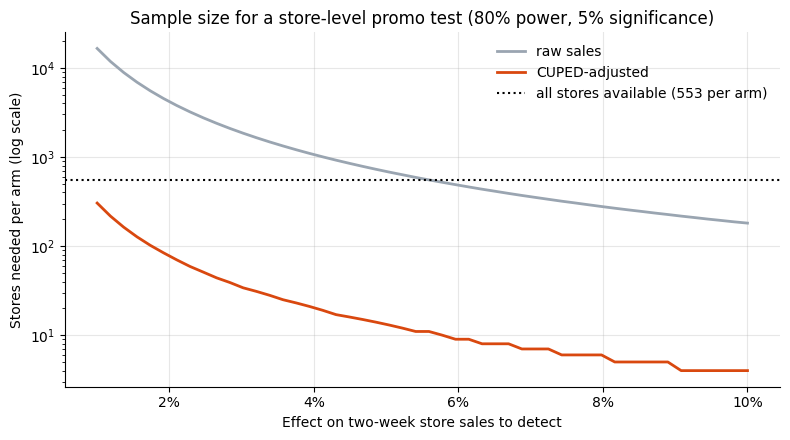

In [29]:
mdes = np.linspace(0.01, 0.10, 50)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(mdes, [stores_per_arm(m, sd_raw) for m in mdes], color="#9aa5b1", lw=2, label="raw sales")
ax.plot(mdes, [stores_per_arm(m, sd_cuped) for m in mdes], color=COLORS["lightgbm"], lw=2, label="CUPED-adjusted")
ax.axhline(n_available, color="black", ls=":", label=f"all stores available ({n_available} per arm)")
ax.set_yscale("log")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Effect on two-week store sales to detect")
ax.set_ylabel("Stores needed per arm (log scale)")
ax.set_title("Sample size for a store-level promo test (80% power, 5% significance)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_test_sample_size.png", dpi=150)
plt.show()

**Design notes.** If promotions are advertised regionally (flyers, local media), randomize by region rather
than by store to avoid control stores seeing the promo. That leaves fewer units, which makes CUPED even more
valuable. Pre-register the metric, the two-week window, and the analysis before launch.

## 8. Key numbers

In [28]:
key_numbers = {
    "Store-days analyzed": f"{len(df):,}",
    "Promo lift (95% CI)": f"{promo_lift:.1%} ({promo_lo:.1%} to {promo_hi:.1%})",
    "Lowest / highest lift by store type": (
        f"type {lift_by_type.loc[lift_by_type.lift.idxmin(), 'store_type']} {lift_by_type.lift.min():.0%} / "
        f"type {lift_by_type.loc[lift_by_type.lift.idxmax(), 'store_type']} {lift_by_type.lift.max():.0%}"),
    "Store-month WAPE: LightGBM": f"{lgb_wape:.1%}",
    "Store-month WAPE: best baseline": f"{best_baseline_wape:.1%}",
    "Error reduction vs best baseline": f"{1 - lgb_wape / best_baseline_wape:.0%}",
    "Chain-level monthly error, LightGBM (avg abs)": f"{summary.loc['lightgbm', 'abs_chain_error']:.1%}",
    "Store-month forecasts within ±10%": f"{within[0.10]:.0%}",
    "July promo calendar value (vs no promo)": f"{(planned - no_promo) / 1e6:.1f}M (+{planned / no_promo - 1:.1%})",
    "Extra promo week value (vs planned)": f"{(extra - planned) / 1e6:.1f}M (+{extra / planned - 1:.1%})",
    "Months LightGBM beat or tied both baselines": f"{lgb_wins} of {len(pivot)}",
    "Variance reduction from CUPED": f"{1 - (sd_cuped / sd_raw) ** 2:.0%}",
    "Stores per arm for +3% (raw vs CUPED)": f"{stores_per_arm(0.03, sd_raw):,} vs {stores_per_arm(0.03, sd_cuped):,}",
}
pd.Series(key_numbers).to_frame("value")

,value
Store-days analyzed,"844,338"
Promo lift (95% CI),39.3% (36.7% to 42.0%)
Lowest / highest lift by store type,type b 13% / type a 44%
Store-month WAPE: LightGBM,3.7%
Store-month WAPE: best baseline,5.5%
Error reduction vs best baseline,34%
"Chain-level monthly error, LightGBM (avg abs)",2.0%
Store-month forecasts within ±10%,97%
July promo calendar value (vs no promo),30.0M (+16.6%)
Extra promo week value (vs planned),12.0M (+5.7%)
